In [1]:
"""
Central configuration for the Mobile Century TSE project.

Every path the project needs lives here, in ONE place. Nothing else in the
codebase should hardcode a folder path. Two reasons this matters:
  1. When the repo is public, another person changes one line to run it.
  2. The data itself is never committed (license forbids redistribution),
     so code and data must stay decoupled.
"""

from pathlib import Path

# Root of the extracted dataset on this machine.
DATA_ROOT = Path(r"D:\Transportation\Data\MobileCentury_data_final_ver3")

# Subfolders. The "/" operator on a Path joins path segments, and pathlib
# handles the OS-correct separator for us.
GPS_LOGS = DATA_ROOT / "GPS_logs"    # 77 raw per-device phone logs
NB_TRIPS = DATA_ROOT / "NB_veh_files"  # northbound trips (one file per pass)
SB_TRIPS = DATA_ROOT / "SB_veh_files"  # southbound trips

In [2]:
from pathlib import Path
root = Path(r"D:\Transportation\MobileCentury-TSE")
for p in sorted(root.iterdir()):
    print(("DIR  " if p.is_dir() else "FILE ") + p.name)

DIR  .git
DIR  .TRSP
DIR  .vscode
DIR  __pycache__
FILE config.py
DIR  data
FILE MobileCentury.ipynb


In [3]:

# Path.cwd() is the notebook's working directory, which we already confirmed
# is the project root: D:\Transportation\MobileCentury-TSE
root = Path.cwd()

# The file's contents, written as a triple-quoted string. Note the doubled
# backslashes (\\) inside DATA_ROOT: this text is passed through Python twice
# (once here, once when config.py is later imported), so each backslash must
# be escaped to survive the first pass intact.
config_text = '''"""Central configuration for the Mobile Century TSE project."""

from pathlib import Path

# Root of the extracted dataset on this machine.
DATA_ROOT = Path(r"D:\\Transportation\\Data\\MobileCentury_data_final_ver3")

GPS_LOGS = DATA_ROOT / "GPS_logs"
NB_TRIPS = DATA_ROOT / "NB_veh_files"
SB_TRIPS = DATA_ROOT / "SB_veh_files"
'''

# write_text() creates the file and writes the string in one call.
(root / "config.py").write_text(config_text, encoding="utf-8")

# Verify: confirm it exists, then print it back so you can see exactly
# what landed on disk.
print("Created at:", root / "config.py")
print("Exists:", (root / "config.py").exists())
print("\n--- file contents ---")
print((root / "config.py").read_text())

Created at: d:\Transportation\MobileCentury-TSE\config.py
Exists: True

--- file contents ---
"""Central configuration for the Mobile Century TSE project."""

from pathlib import Path

# Root of the extracted dataset on this machine.
DATA_ROOT = Path(r"D:\Transportation\Data\MobileCentury_data_final_ver3")

GPS_LOGS = DATA_ROOT / "GPS_logs"
NB_TRIPS = DATA_ROOT / "NB_veh_files"
SB_TRIPS = DATA_ROOT / "SB_veh_files"



In [4]:
import sys


# Path.cwd() is the project root, and config.py now lives there. Adding it to
# sys.path lets Python find the module. insert(0, ...) puts it first in the
# search order; the "if not in" guard prevents the list growing on re-runs.
root = Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from config import DATA_ROOT, GPS_LOGS, NB_TRIPS, SB_TRIPS

# Verify each path resolves to something real on disk. A False here means the
# folder name in config.py doesn't match what's actually in your data
# directory -- which is likely, since your folder is the "_final_ver3" build
# and may differ from the download page's documented layout.
for name, p in [("DATA_ROOT", DATA_ROOT),
                ("GPS_LOGS", GPS_LOGS),
                ("NB_TRIPS", NB_TRIPS),
                ("SB_TRIPS", SB_TRIPS)]:
    print(f"{name:<10} exists={str(p.exists()):<6} {p}")

DATA_ROOT  exists=True   D:\Transportation\Data\MobileCentury_data_final_ver3
GPS_LOGS   exists=True   D:\Transportation\Data\MobileCentury_data_final_ver3\GPS_logs
NB_TRIPS   exists=True   D:\Transportation\Data\MobileCentury_data_final_ver3\NB_veh_files
SB_TRIPS   exists=True   D:\Transportation\Data\MobileCentury_data_final_ver3\SB_veh_files


In [5]:
# Purpose: inventory the dataset. We list the top level to see every CSV and
# folder, then count files in each trip folder. This tells us the real scale
# of what we're working with before we write any parsing code.

print("--- Top-level contents ---")
for p in sorted(DATA_ROOT.iterdir()):
    kind = "DIR " if p.is_dir() else "FILE"
    print(f"  {kind}  {p.name}")

print("\n--- File counts ---")
# glob("*") yields every entry in the folder; wrapping in list() lets us
# count them. Expect ~77 GPS logs (one per device) but far more trip files
# (one per directional pass), which is the distinction we discussed earlier.
for name, folder in [("GPS_logs", GPS_LOGS),
                     ("NB_veh_files", NB_TRIPS),
                     ("SB_veh_files", SB_TRIPS)]:
    print(f"  {name:<14} {len(list(folder.glob('*')))} files")

--- Top-level contents ---
  DIR   GPS_logs
  FILE  ground_truth_traveltimes_1_NB.csv
  FILE  ground_truth_traveltimes_2_NB.csv
  DIR   NB_veh_files
  FILE  pems_prop_NB.csv
  FILE  pems_prop_SB.csv
  FILE  pems_rawdata_NB.csv
  FILE  pems_rawdata_SB.csv
  DIR   SB_veh_files
  FILE  vtl_data_NB.csv
  FILE  vtl_data_SB.csv

--- File counts ---
  GPS_logs       77 files
  NB_veh_files   1388 files
  SB_veh_files   1512 files


In [6]:
# Purpose: inspect the literal raw text of one file from each category.
# We're looking for four things:
#   1. Is there a header row, or does the file start straight into numbers?
#   2. What separates the values -- comma, tab, or whitespace?
#   3. How many columns, and in what order?
#   4. Timestamp magnitude: ~10 digits = seconds, ~13 digits = milliseconds.
# Point 4 is the units trap -- GPS logs are documented as milliseconds while
# everything else is seconds, and mixing them silently breaks time alignment.

def peek(path, label, n_chars=350):
    """Print a file's name and its first n_chars as raw text."""
    print(f"--- {label}: {path.name} ---")
    print(path.read_text()[:n_chars])
    print()

# First file from each trip folder (sorted so the result is reproducible).
peek(sorted(NB_TRIPS.glob("*"))[0], "NB trip")
peek(sorted(GPS_LOGS.glob("*"))[0], "GPS log")

# One of each top-level CSV type.
peek(DATA_ROOT / "pems_prop_NB.csv", "PeMS detector locations")
peek(DATA_ROOT / "pems_rawdata_NB.csv", "PeMS loop readings")

--- NB trip: veh_1.csv ---


unix time, latitude, longitude, postmile, speed
1202497980,37.531738571,-122.005581047,17.642532,53.751
1202497984,37.532282138,-122.006584528,17.705566,57.484
1202497987,37.532702490,-122.007358010,17.754559,59.903
1202497991,37.533291151,-122.008440532,17.823260,62.299
1202497994,37.533733883,-122.009251900,17.874832,63.522
1202497998,37.53432363

--- GPS log: veh101.csv ---
unixtime,latitude,longitude,speed
1202497202837,37.6004328519,-122.0637571325,0.009
1202497206836,37.6004329358,-122.0637568810,0.010
1202497209837,37.6004329358,-122.0637566295,0.013
1202497212837,37.6004329358,-122.0637563781,0.015
1202497216826,37.6004330196,-122.0637560428,0.016
1202497220826,37.6004331872,-122.0637556237,0.017
1202497224823,37

--- PeMS detector locations: pems_prop_NB.csv ---
"pems_id","abs_pm","lat","lon"
400662,16.447,37.5223526785006,-121.987184381083
400141,16.597,37.5235000105891,-121.989505022237
400490,17.587,37.5312559704738,-122.004693240276
401888,18.657,37.5415595739491,-122.0188

In [7]:
# Purpose: inspect the last two file categories -- the video-based travel
# time ground truth, and the virtual trip line data. We also check a
# SOUTHBOUND trip file to confirm it shares the northbound format, since
# we'll want one loader that handles both directions.

def peek(path, label, n_chars=350):
    print(f"--- {label}: {path.name} ---")
    print(path.read_text()[:n_chars])
    print()

peek(DATA_ROOT / "ground_truth_traveltimes_1_NB.csv", "Travel times (segment 1)")
peek(DATA_ROOT / "vtl_data_NB.csv", "Virtual trip lines")
peek(sorted(SB_TRIPS.glob("*"))[0], "SB trip")

--- Travel times (segment 1): ground_truth_traveltimes_1_NB.csv ---
"departure_time" (unix time, UTC), "travel_time" (seconds)
1202508342,158
1202508320,152
1202508335,159
1202508360,150
1202508333,162
1202508326,168
1202508331,175
1202508331,175
1202508346,165
1202508330,189
1202508360,147
1202508329,152
1202508331,151
1202508333,153
1202508338,152
1202508329,169
1202508346,152
1202508359,147
1202508344,165
120250

--- Virtual trip lines: vtl_data_NB.csv ---
"fk_vtl_id","timestamp2unix","coordinate","vel_mph"
-63,1202494798,"(-122.0982,37.6515)",56
-63,1202494878,"(-122.0982,37.6515)",49
-63,1202495946,"(-122.0984,37.6515)",39
-63,1202496704,"(-122.0983,37.6515)",61
-63,1202496965,"(-122.0982,37.6515)",53
-63,1202498930,"(-122.0982,37.6515)",49
-63,1202499956,"(-122.0982,37.6515)",52
-63,1202500088,"(-

--- SB trip: veh_1.csv ---
unix time, latitude, longitude, postmile, speed
1202497543,37.595717530,-122.059081541,-23.050337,55.449
1202497547,37.594926698,-122.058479553,-22.986736,56

In [8]:
# Purpose: the first reusable loader. Reads a single trip file into a pandas
# DataFrame with clean, consistent column names, and adds metadata columns
# we'll need later (which trip, which direction).
#
# Design notes:
#  - Trip files use "unix time" with a space; we rename to "unixtime" so all
#    data sources in this project share one naming convention.
#  - Timestamps here are SECONDS (10 digits), unlike GPS_logs (milliseconds).
#  - Postmiles are negative southbound; we keep the raw value AND add an
#    absolute version, so nothing is lost but downstream code stays simple.

import pandas as pd

def load_trip(path, direction):
    """
    Load one trip file (a single directional pass by one vehicle).

    Parameters
    ----------
    path : Path       - the .csv file to read
    direction : str   - "NB" or "SB"

    Returns
    -------
    DataFrame with columns:
        unixtime, latitude, longitude, postmile, speed,
        postmile_abs, trip_id, direction
    """
    # skipinitialspace strips the blank after each comma in the header,
    # otherwise columns come back named " latitude" with a leading space.
    df = pd.read_csv(path, skipinitialspace=True)

    # Normalize the timestamp column name across all data sources.
    df = df.rename(columns={"unix time": "unixtime"})

    # Direction-independent position along the corridor.
    df["postmile_abs"] = df["postmile"].abs()

    # Provenance: which file this row came from, and which direction.
    # path.stem is the filename without extension, e.g. "veh_1".
    df["trip_id"] = path.stem
    df["direction"] = direction

    return df


# Test on one file from each direction.
nb = load_trip(sorted(NB_TRIPS.glob("*.csv"))[0], "NB")
sb = load_trip(sorted(SB_TRIPS.glob("*.csv"))[0], "SB")

print("NB shape:", nb.shape)
print(nb.head(3))
print("\nSB shape:", sb.shape)
print(sb.head(3))
print("\nColumn dtypes:")
print(nb.dtypes)

NB shape: (297, 8)
     unixtime   latitude   longitude   postmile   speed  postmile_abs trip_id  \
0  1202497980  37.531739 -122.005581  17.642532  53.751     17.642532   veh_1   
1  1202497984  37.532282 -122.006585  17.705566  57.484     17.705566   veh_1   
2  1202497987  37.532702 -122.007358  17.754559  59.903     17.754559   veh_1   

  direction  
0        NB  
1        NB  
2        NB  

SB shape: (90, 8)
     unixtime   latitude   longitude   postmile   speed  postmile_abs trip_id  \
0  1202497543  37.595718 -122.059082 -23.050337  55.449     23.050337   veh_1   
1  1202497547  37.594927 -122.058480 -22.986736  56.856     22.986736   veh_1   
2  1202497551  37.594119 -122.057886 -22.922613  58.125     22.922613   veh_1   

  direction  
0        SB  
1        SB  
2        SB  

Column dtypes:
unixtime          int64
latitude        float64
longitude       float64
postmile        float64
speed           float64
postmile_abs    float64
trip_id             str
direction       

In [9]:
# Purpose: load all ~2900 trip files into a single DataFrame. This is the
# complete probe dataset -- the ESTIMATOR INPUT side of the project.
#
# Change from the previous block: trip_id is now prefixed with direction
# ("NB_veh_1") because both folders contain a file named veh_1.csv. Without
# the prefix, two unrelated trips would share an identifier and any later
# groupby() on trip_id would silently merge them.

import pandas as pd

def load_trip(path, direction):
    """Load one trip file into a DataFrame with normalized columns."""
    df = pd.read_csv(path, skipinitialspace=True)
    df = df.rename(columns={"unix time": "unixtime"})
    df["postmile_abs"] = df["postmile"].abs()
    df["trip_id"] = f"{direction}_{path.stem}"   # globally unique
    df["direction"] = direction
    return df


def load_all_trips(folder, direction):
    """Load every trip file in a folder and stack them into one DataFrame."""
    files = sorted(folder.glob("*.csv"))
    # Build a list of DataFrames first, then concat ONCE. Appending to a
    # DataFrame inside a loop is quadratic and would be painfully slow here.
    frames = [load_trip(f, direction) for f in files]
    # ignore_index=True renumbers rows 0..N instead of repeating each file's
    # own 0-based index.
    return pd.concat(frames, ignore_index=True)


probes_nb = load_all_trips(NB_TRIPS, "NB")
probes_sb = load_all_trips(SB_TRIPS, "SB")
probes = pd.concat([probes_nb, probes_sb], ignore_index=True)

print("NB rows:", len(probes_nb), "| trips:", probes_nb.trip_id.nunique())
print("SB rows:", len(probes_sb), "| trips:", probes_sb.trip_id.nunique())
print("Total rows:", len(probes))

# Summary of the value ranges. This is a sanity check: look for impossible
# speeds (negative, or absurdly high) and confirm the postmile span matches
# the ~10-mile study corridor.
print("\n--- Value ranges ---")
print(probes[["unixtime", "postmile_abs", "speed"]].describe())

NB rows: 235586 | trips: 1388
SB rows: 151530 | trips: 1512
Total rows: 387116

--- Value ranges ---
           unixtime   postmile_abs          speed
count  3.871160e+05  387116.000000  387116.000000
mean   1.202509e+09      23.466765      42.616946
std    8.669692e+03       2.388396      21.714136
min    1.202492e+09      16.554623       0.004000
25%    1.202501e+09      21.988482      23.465000
50%    1.202508e+09      24.039200      45.586000
75%    1.202516e+09      25.273460      62.717000
max    1.202526e+09      27.803652      94.404000


In [10]:
# Purpose: convert unix timestamps into readable datetimes, and add a
# "seconds since experiment start" column for plotting.
#
# Why both: pandas datetimes are readable and handle timezones correctly,
# but plotting against elapsed seconds/hours is far easier to reason about
# when we build the space-time grid.
#
# TIMEZONE NOTE: unix timestamps are UTC by definition. The experiment ran
# in California (Pacific), which in February is UTC-8. We convert so the
# clock times match when the experiment actually happened locally.

# unit="s" tells pandas these are SECONDS (not the milliseconds used in
# GPS_logs). utc=True marks them as UTC before converting to local time.
probes["datetime_utc"] = pd.to_datetime(probes["unixtime"], unit="s", utc=True)
probes["datetime_local"] = probes["datetime_utc"].dt.tz_convert("America/Los_Angeles")

# Elapsed time from the first observation, in hours -- our plotting x-axis.
t0 = probes["unixtime"].min()
probes["hours_elapsed"] = (probes["unixtime"] - t0) / 3600.0

print("Experiment start (local):", probes["datetime_local"].min())
print("Experiment end   (local):", probes["datetime_local"].max())
print("Duration (hours):", round(probes["hours_elapsed"].max(), 2))
print("Date:", probes["datetime_local"].dt.date.min())

# How many probe observations per hour of the day? This shows whether
# coverage was uniform or concentrated in certain periods.
print("\n--- Observations per local hour ---")
print(probes["datetime_local"].dt.hour.value_counts().sort_index())

Experiment start (local): 2008-02-08 09:33:47-08:00
Experiment end   (local): 2008-02-08 18:57:13-08:00
Duration (hours): 9.39
Date: 2008-02-08

--- Observations per local hour ---
datetime_local
9       330
10    41834
11    49738
12    51180
13    48836
14    45018
15    44097
16    48712
17    31398
18    25973
Name: count, dtype: int64


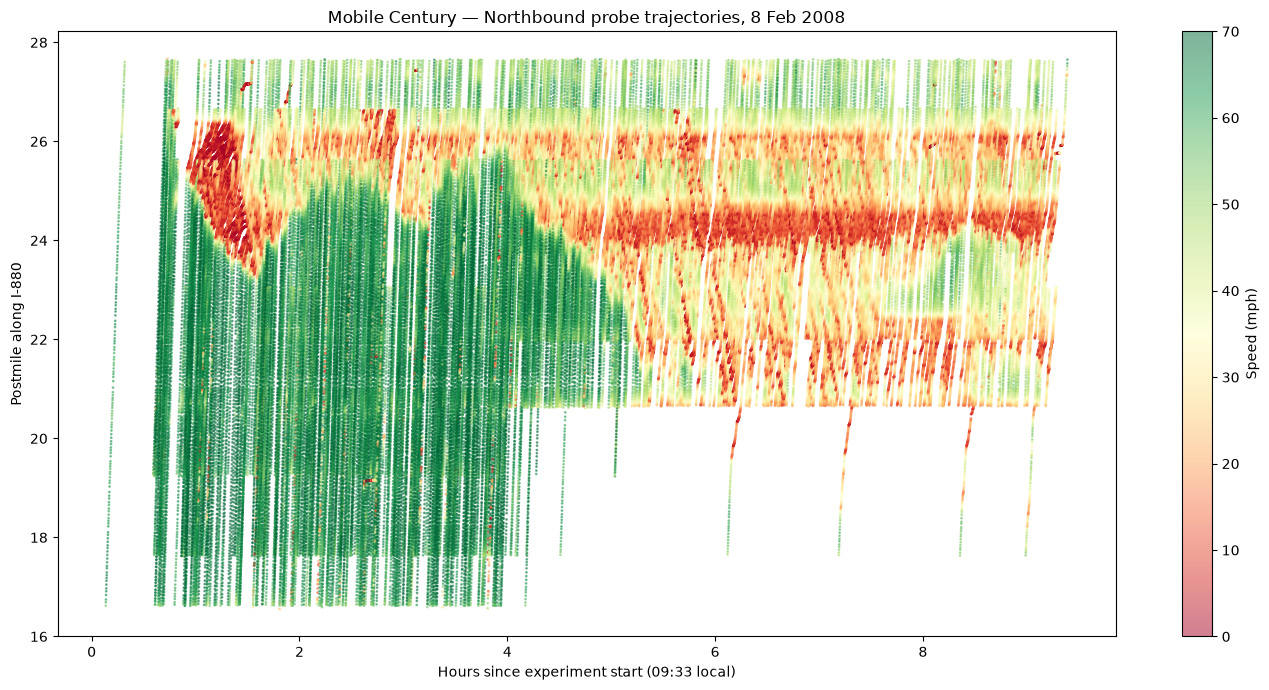

In [11]:
# Purpose: the time-space diagram, the fundamental visualization in traffic
# engineering. Time on the x-axis, position along the road on the y-axis,
# and each probe observation colored by its speed.
#
# How to read it: each probe trip traces a diagonal line (a car moving
# forward through space and time). The SLOPE of that line is its speed --
# steep means fast, flat means stopped. Where many trips slow down at the
# same place and time, you get a dark region: congestion. If that dark
# region drifts BACKWARD (upstream) as time advances, you're seeing a
# shockwave -- a queue propagating against the direction of travel.
#
# We plot northbound only. Mixing directions would overlay two unrelated
# traffic states on the same axes and make the picture meaningless.

import matplotlib.pyplot as plt

nb = probes[probes["direction"] == "NB"]

fig, ax = plt.subplots(figsize=(14, 7))

# s=1 keeps markers tiny -- with 235k points, larger markers would merge
# into a solid block. cmap "RdYlGn" maps low speeds to red, high to green,
# which matches the color convention people already know from map apps.
sc = ax.scatter(
    nb["hours_elapsed"],
    nb["postmile_abs"],
    c=nb["speed"],
    s=1,
    cmap="RdYlGn",
    vmin=0, vmax=70,     # fixed scale so colors mean the same thing always
    alpha=0.5,
)

ax.set_xlabel("Hours since experiment start (09:33 local)")
ax.set_ylabel("Postmile along I-880")
ax.set_title("Mobile Century — Northbound probe trajectories, 8 Feb 2008")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Speed (mph)")

plt.tight_layout()
plt.show()

Grid: 113 space bins x 565 time bins
Cells with probe data: 35,600 of ~63,845 (55.8%)


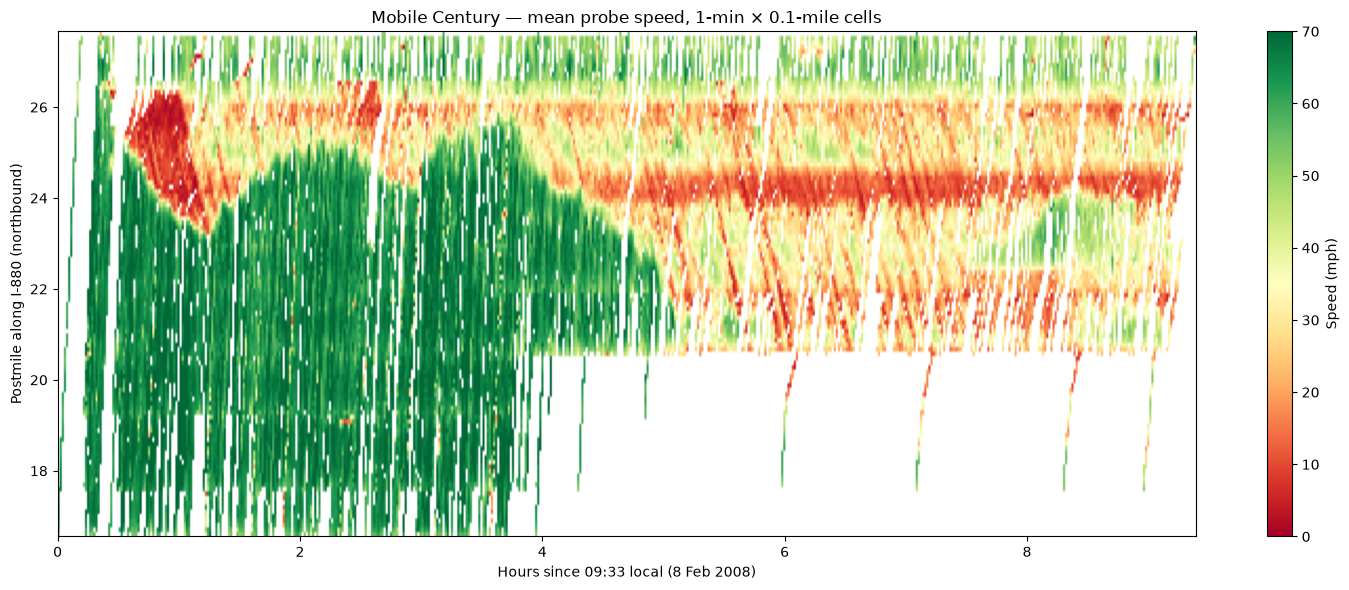

In [12]:
# Purpose: replace the overplotted scatter with a binned heatmap. Instead of
# drawing 235k individual points, we divide the space-time plane into a grid
# of cells and color each cell by the MEAN probe speed inside it.
#
# Why this is better:
#  - Overplotting disappears; each cell shows one aggregated value.
#  - It is literally a preview of the estimation target -- the grid we build
#    here is the same structure the estimator will fill in.
#  - Empty cells (no probe passed through) render as blank, honestly showing
#    where we have NO information rather than implying smooth data.

import numpy as np

nb = probes[probes["direction"] == "NB"]

# Grid resolution. 1-minute time bins, 0.1-mile space bins.
# Finer bins = more detail but more empty cells; coarser = smoother but
# blurs the shockwave. These are a reasonable starting point to tune.
time_bins = np.arange(0, nb["hours_elapsed"].max() + 1/60, 1/60)   # 1 min
space_bins = np.arange(nb["postmile_abs"].min(),
                       nb["postmile_abs"].max() + 0.1, 0.1)         # 0.1 mi

# Assign each observation to a cell, then average speeds within each cell.
# pd.cut() labels each row with its bin index.
nb_binned = nb.assign(
    t_bin=pd.cut(nb["hours_elapsed"], time_bins, labels=False),
    x_bin=pd.cut(nb["postmile_abs"], space_bins, labels=False),
)

# pivot_table builds the 2D grid: rows = space, columns = time, values = mean
# speed. Cells with no observations become NaN and will render as blank.
grid = nb_binned.pivot_table(
    index="x_bin", columns="t_bin", values="speed", aggfunc="mean"
)

# Report coverage -- what fraction of the grid actually has probe data?
# This number is central to your whole project: it quantifies the sparsity
# the estimator has to overcome.
total_cells = len(space_bins) * len(time_bins)
filled = grid.notna().sum().sum()
print(f"Grid: {len(space_bins)} space bins x {len(time_bins)} time bins")
print(f"Cells with probe data: {filled:,} of ~{total_cells:,} "
      f"({100*filled/total_cells:.1f}%)")

fig, ax = plt.subplots(figsize=(15, 6))

# imshow draws the 2D array directly. extent maps array indices back to real
# units on the axes. origin="lower" puts low postmiles at the bottom.
# aspect="auto" lets the plot fill the figure rather than forcing square cells.
im = ax.imshow(
    grid.values,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    vmin=0, vmax=70,
    extent=[0, nb["hours_elapsed"].max(),
            nb["postmile_abs"].min(), nb["postmile_abs"].max()],
)

ax.set_xlabel("Hours since 09:33 local (8 Feb 2008)")
ax.set_ylabel("Postmile along I-880 (northbound)")
ax.set_title("Mobile Century — mean probe speed, 1-min × 0.1-mile cells")
fig.colorbar(im, ax=ax, label="Speed (mph)")

plt.tight_layout()
plt.show()

In [13]:
# Purpose: fix the study domain and measure probe sparsity honestly.
#
# Two decisions being made here:
#  1. Restrict to postmile 20.6-27.8, where coverage is continuous for the
#     whole 9.4 hours. Below 20.6 the probes stop running after ~hour 4, and
#     estimating a region with no observations would be dishonest.
#  2. Report coverage at several grid resolutions, because "how sparse is
#     this data" has no single answer -- it depends entirely on cell size.
#     This is the sparsity your estimator must overcome.

PM_MIN, PM_MAX = 20.6, 27.8

nb = probes[probes["direction"] == "NB"]
nb_study = nb[(nb["postmile_abs"] >= PM_MIN) & (nb["postmile_abs"] <= PM_MAX)]

print(f"Rows in study domain: {len(nb_study):,} of {len(nb):,} "
      f"({100*len(nb_study)/len(nb):.1f}% retained)")
print(f"Trips represented: {nb_study.trip_id.nunique()}")

T_MAX = nb_study["hours_elapsed"].max()

print("\n--- Coverage vs grid resolution ---")
# Test several (time, space) resolutions to see how coverage responds.
for dt_min, dx_mile in [(0.5, 0.05), (1, 0.1), (2, 0.1), (5, 0.2)]:
    t_edges = np.arange(0, T_MAX + dt_min/60, dt_min/60)
    x_edges = np.arange(PM_MIN, PM_MAX + dx_mile, dx_mile)

    # histogram2d counts observations per cell -- faster than pivot_table
    # when we only need counts, not means.
    counts, _, _ = np.histogram2d(
        nb_study["hours_elapsed"], nb_study["postmile_abs"],
        bins=[t_edges, x_edges]
    )
    total = counts.size
    filled = (counts > 0).sum()
    print(f"  {dt_min:>4} min x {dx_mile:.2f} mi : "
          f"{filled:>7,} / {total:>7,} cells filled ({100*filled/total:5.1f}%)")

Rows in study domain: 211,094 of 235,586 (89.6% retained)
Trips represented: 1387

--- Coverage vs grid resolution ---
   0.5 min x 0.05 mi :  77,673 / 162,288 cells filled ( 47.9%)
     1 min x 0.10 mi :  29,053 /  40,608 cells filled ( 71.5%)
     2 min x 0.10 mi :  16,944 /  20,304 cells filled ( 83.5%)
     5 min x 0.20 mi :   3,757 /   4,068 cells filled ( 92.4%)


In [14]:
# Purpose: confirm that subsampling trips actually produces the sparsity this
# project needs. We drop from 1387 NB trips down to realistic penetration
# rates and re-measure coverage on the SAME 1-min x 0.1-mile grid.
#
# Why subsample by TRIP and not by row: a real deployment has a fraction of
# VEHICLES reporting, and each reporting vehicle sends its whole trajectory.
# Randomly dropping individual GPS points would simulate a different thing
# entirely (a lossy sensor), and would leave every trip partially visible --
# far easier than reality. Dropping whole trips is the honest simulation.

import numpy as np

PM_MIN, PM_MAX = 20.6, 27.8
nb_study = probes[(probes["direction"] == "NB")
                  & (probes["postmile_abs"].between(PM_MIN, PM_MAX))]

T_MAX = nb_study["hours_elapsed"].max()
t_edges = np.arange(0, T_MAX + 1/60, 1/60)          # 1 minute
x_edges = np.arange(PM_MIN, PM_MAX + 0.1, 0.1)      # 0.1 mile

all_trips = nb_study["trip_id"].unique()
rng = np.random.default_rng(42)   # fixed seed = reproducible results

print(f"Full set: {len(all_trips)} trips\n")
print("  rate   trips     rows    coverage")
print("  " + "-"*36)

for rate in [1.0, 0.5, 0.25, 0.10, 0.05, 0.02]:
    n = max(1, int(len(all_trips) * rate))
    # replace=False so we sample distinct trips, not the same one twice.
    chosen = rng.choice(all_trips, size=n, replace=False)
    sub = nb_study[nb_study["trip_id"].isin(chosen)]

    counts, _, _ = np.histogram2d(
        sub["hours_elapsed"], sub["postmile_abs"], bins=[t_edges, x_edges]
    )
    cov = 100 * (counts > 0).sum() / counts.size
    print(f"  {rate:>4.0%}   {n:>5}  {len(sub):>7,}    {cov:>5.1f}%")

Full set: 1387 trips

  rate   trips     rows    coverage
  ------------------------------------
  100%    1387  211,094     71.5%
   50%     693  105,278     53.5%
   25%     346   52,195     34.8%
   10%     138   19,928     15.8%
    5%      69   10,609      8.8%
    2%      27    4,191      3.4%


In [15]:
# Purpose: build and save the REFERENCE FIELD -- the space-time speed grid
# from ALL available probes. At 71.5% coverage this is close to a direct
# measurement, so it serves as one of our two validation targets.
#
# Note the remaining 28.5% of cells are still empty even at full penetration.
# We leave them as NaN rather than interpolating. Filling them would mean
# inventing data and then scoring estimators against our own invention.
# NaN cells will simply be excluded when computing error metrics.

import numpy as np
import pandas as pd

PM_MIN, PM_MAX = 20.6, 27.8
DT_MIN, DX_MILE = 1.0, 0.1

nb_study = probes[(probes["direction"] == "NB")
                  & (probes["postmile_abs"].between(PM_MIN, PM_MAX))].copy()

T_MAX = nb_study["hours_elapsed"].max()
t_edges = np.arange(0, T_MAX + DT_MIN/60, DT_MIN/60)
x_edges = np.arange(PM_MIN, PM_MAX + DX_MILE, DX_MILE)

def build_field(df, t_edges, x_edges):
    """
    Aggregate probe observations into a 2D mean-speed grid.

    Returns a (n_space, n_time) array. Cells with no observations are NaN.
    Orientation is space-by-time so it plots directly with imshow.
    """
    # Sum of speeds per cell, and count per cell. Dividing gives the mean
    # while letting us detect empty cells (count == 0) explicitly.
    sums, _, _ = np.histogram2d(
        df["postmile_abs"], df["hours_elapsed"],
        bins=[x_edges, t_edges], weights=df["speed"]
    )
    counts, _, _ = np.histogram2d(
        df["postmile_abs"], df["hours_elapsed"], bins=[x_edges, t_edges]
    )

    # np.errstate suppresses the divide-by-zero warning; we handle it via where.
    with np.errstate(invalid="ignore", divide="ignore"):
        field = np.where(counts > 0, sums / counts, np.nan)
    return field, counts

reference_field, reference_counts = build_field(nb_study, t_edges, x_edges)

print("Reference field shape (space, time):", reference_field.shape)
print(f"Cells with data: {np.isfinite(reference_field).sum():,} "
      f"({100*np.isfinite(reference_field).mean():.1f}%)")
print(f"Speed range: {np.nanmin(reference_field):.1f} - "
      f"{np.nanmax(reference_field):.1f} mph")
print(f"Mean speed:  {np.nanmean(reference_field):.1f} mph")

# Distribution across traffic regimes. This matters because your evaluation
# should report congested-cell error separately -- a method can score well
# overall while failing exactly where it counts.
finite = reference_field[np.isfinite(reference_field)]
print(f"\nCongested cells (<30 mph): {100*(finite < 30).mean():.1f}%")
print(f"Transition   (30-50 mph):  {100*((finite >= 30) & (finite < 50)).mean():.1f}%")
print(f"Free-flow    (>=50 mph):   {100*(finite >= 50).mean():.1f}%")

Reference field shape (space, time): (72, 564)
Cells with data: 29,053 (71.5%)
Speed range: 0.5 - 87.1 mph
Mean speed:  42.0 mph

Congested cells (<30 mph): 32.2%
Transition   (30-50 mph):  29.0%
Free-flow    (>=50 mph):   38.8%


In [16]:
# Purpose: persist the processed data so later notebooks don't re-parse 2900
# CSVs. We save to a "processed" folder inside the PROJECT (not the data
# directory), and it stays gitignored -- these are derived artifacts, not
# source, and they're reproducible from the loader code.
#
# Formats:
#  - Parquet for the probe DataFrame: compact, fast, preserves dtypes.
#    (CSV would lose the datetime types and be ~10x larger.)
#  - .npz for the grid arrays: numpy's native multi-array container.



OUT = Path.cwd() / "data" / "processed"
OUT.mkdir(parents=True, exist_ok=True)   # creates both levels if missing

# Drop the timezone-aware datetime columns before saving to parquet -- they
# occasionally cause engine compatibility issues, and unixtime reconstructs
# them in one line anyway.
to_save = nb_study.drop(columns=["datetime_utc", "datetime_local"],
                        errors="ignore")
to_save.to_parquet(OUT / "probes_nb_study.parquet", index=False)

# Save the grid, its axes, and the observation counts together so the field
# can be reloaded with full context.
np.savez_compressed(
    OUT / "reference_field.npz",
    field=reference_field,
    counts=reference_counts,
    t_edges=t_edges,
    x_edges=x_edges,
)

print("Saved to:", OUT)
for f in sorted(OUT.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")

Saved to: d:\Transportation\MobileCentury-TSE\data\processed
  probes_nb_study.parquet  (9.5 MB)
  reference_field.npz  (0.2 MB)


In [17]:
# Purpose: tell git what NOT to track. Two categories matter here:
#
#  1. Your virtual environment (.TRSP) -- thousands of files, machine-
#     specific, and rebuildable from requirements.txt. Committing it is the
#     single most common way people bloat a repo.
#  2. The data/ folder -- the Mobile Century license forbids redistribution,
#     so raw data and derived artifacts both stay out. Anyone cloning your
#     repo downloads the data themselves and re-runs the loaders.

gitignore = """# Virtual environment
.TRSP/
.venv/

# Python
__pycache__/
*.pyc

# Jupyter
.ipynb_checkpoints/

# Data -- NOT redistributable (Mobile Century license) and reproducible
data/

# Editor
.vscode/
"""

from pathlib import Path
(Path.cwd() / ".gitignore").write_text(gitignore, encoding="utf-8")

# Confirm git now ignores the data folder. If this prints nothing, something
# is wrong -- check-ignore only outputs paths it will actually exclude.
import subprocess
print((Path.cwd() / ".gitignore").read_text())
print("--- git check ---")
print(subprocess.run(["git", "check-ignore", "-v", "data/processed/probes_nb_study.parquet"],
                     capture_output=True, text=True).stdout or "NOT IGNORED - problem!")

# Virtual environment
.TRSP/
.venv/

# Python
__pycache__/
*.pyc

# Jupyter
.ipynb_checkpoints/

# Data -- NOT redistributable (Mobile Century license) and reproducible
data/

# Editor
.vscode/

--- git check ---
.gitignore:13:data/	data/processed/probes_nb_study.parquet



In [18]:
# Purpose: implement the Adaptive Smoothing Method (Treiber & Helbing 2002),
# our non-ML baseline. Every later method must beat this to justify itself.
#
# The method in three steps:
#   1. Smooth observations along FREE-FLOW characteristics (info moves
#      downstream at c_free, tilting one way in the time-space plane).
#   2. Smooth along CONGESTED characteristics (info moves upstream at
#      c_cong, tilting the other way).
#   3. Blend them with a weight w that depends on the resulting speed --
#      low speeds favor the congested field, high speeds the free-flow one.

import numpy as np

# --- Parameters (Treiber & Helbing's suggested values) ---
C_FREE = 50.0    # mph, downstream propagation speed in free flow
C_CONG = -12.0   # mph, upstream propagation speed in congestion (negative)
SIGMA = 0.3      # miles, spatial smoothing width
TAU = 3.0 / 60   # hours (3 min), temporal smoothing width
V_THRESH = 37.0  # mph, midpoint of the free/congested transition
DELTA_V = 12.0   # mph, width of that transition


def asm_smooth(obs_speed, obs_t, obs_x, grid_t, grid_x, c_prop):
    """
    Smooth scattered observations onto a grid along one characteristic speed.

    For each grid cell, every observation gets a weight from a 2D kernel that
    is TILTED in the time-space plane: an observation upstream and earlier
    (or downstream and later, depending on sign of c_prop) counts as "nearby"
    because information physically travels along that direction.

    obs_speed, obs_t, obs_x : 1D arrays of observations
    grid_t, grid_x          : 1D arrays of cell-center coordinates
    c_prop                  : propagation speed (mph); sign sets the tilt
    """
    n_x, n_t = len(grid_x), len(grid_t)
    out = np.full((n_x, n_t), np.nan)

    # Loop over space rows; vectorize across time and observations within.
    # A fully vectorized version would need an (n_x*n_t, n_obs) array --
    # 40,608 x 211,094 floats, far too large for memory.
    for i, x in enumerate(grid_x):
        # Distance from this row's position to every observation.
        dx = obs_x - x                                   # miles

        for j, t in enumerate(grid_t):
            dt = obs_t - t                               # hours

            # THE KEY LINE: shift time by the travel time along the
            # characteristic. An observation dx miles away is "contemporary"
            # if it occurred dx/c_prop hours offset from now.
            dt_shifted = dt - dx / c_prop

            # Gaussian kernel in shifted coordinates.
            w = np.exp(-(dx**2) / (2 * SIGMA**2)
                       - (dt_shifted**2) / (2 * TAU**2))

            # Ignore negligible weights so distant points don't add noise.
            m = w > 1e-4
            if m.sum() > 0 and w[m].sum() > 0:
                out[i, j] = np.sum(w[m] * obs_speed[m]) / np.sum(w[m])
    return out


def asm_estimate(obs_speed, obs_t, obs_x, grid_t, grid_x):
    """Full ASM: smooth both ways, then blend adaptively."""
    v_free = asm_smooth(obs_speed, obs_t, obs_x, grid_t, grid_x, C_FREE)
    v_cong = asm_smooth(obs_speed, obs_t, obs_x, grid_t, grid_x, C_CONG)

    # Blend weight: use the SLOWER of the two estimates to decide how
    # congested the cell is. tanh gives a smooth 0-to-1 transition.
    v_min = np.fmin(v_free, v_cong)          # fmin ignores NaN where possible
    w = 0.5 * (1 + np.tanh((V_THRESH - v_min) / DELTA_V))

    # w near 1 -> congested -> trust v_cong. w near 0 -> free -> trust v_free.
    return w * v_cong + (1 - w) * v_free


# --- Grid cell centers (edges are boundaries; we estimate at centers) ---
t_centers = (t_edges[:-1] + t_edges[1:]) / 2
x_centers = (x_edges[:-1] + x_edges[1:]) / 2

print(f"Grid: {len(x_centers)} space x {len(t_centers)} time cells")
print(f"Observations available: {len(nb_study):,}")
print("Running ASM on full probe set... (expect 1-3 minutes)")

import time
start = time.time()
asm_full = asm_estimate(
    nb_study["speed"].values,
    nb_study["hours_elapsed"].values,
    nb_study["postmile_abs"].values,
    t_centers, x_centers,
)
print(f"Done in {time.time()-start:.1f}s")
print(f"Cells estimated: {np.isfinite(asm_full).sum():,} of {asm_full.size:,}")
print(f"Speed range: {np.nanmin(asm_full):.1f} - {np.nanmax(asm_full):.1f} mph")

Grid: 72 space x 564 time cells
Observations available: 211,094
Running ASM on full probe set... (expect 1-3 minutes)
Done in 731.8s
Cells estimated: 40,421 of 40,608
Speed range: 4.1 - 73.1 mph


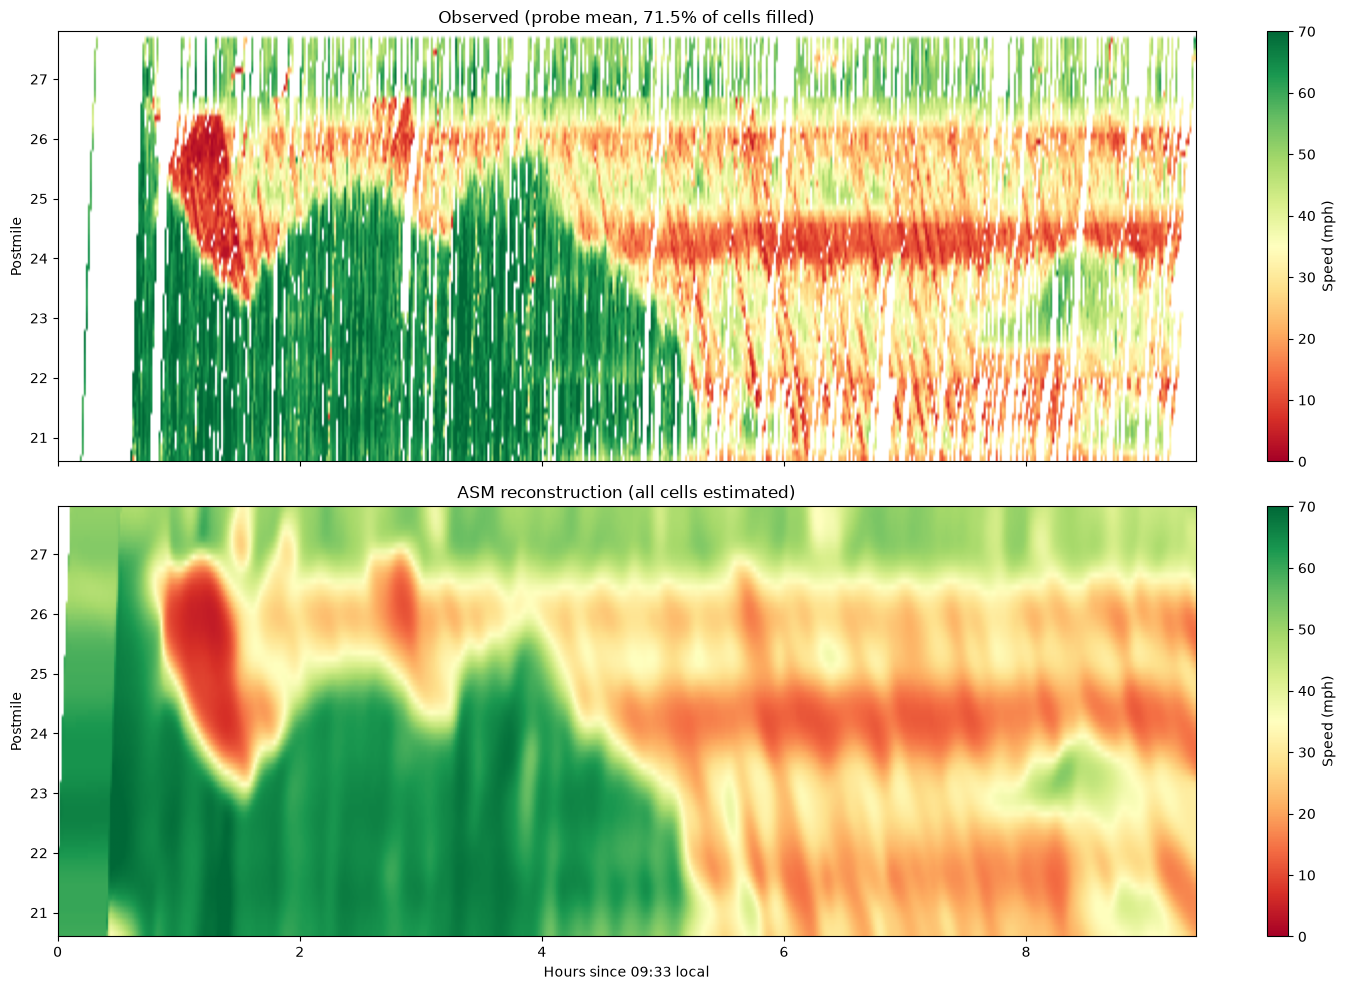

Compared on 29,053 cells
MAE : 5.68 mph
RMSE: 7.66 mph
Bias: -2.52 mph   (positive = ASM over-predicts speed)
  Congested (<30)      MAE  4.47 mph  bias  +1.72  (n=9,365)
  Transition (30-50)   MAE  7.23 mph  bias  -5.61  (n=8,417)
  Free-flow (>=50)     MAE  5.54 mph  bias  -3.75  (n=11,271)


In [19]:
# Purpose: compare the ASM reconstruction against the observed reference
# field side by side. This is a visual sanity check before we trust any
# numbers -- if ASM smeared away the shockwave or invented structure that
# isn't there, we need to know before building on it.

import matplotlib.pyplot as plt

extent = [0, t_edges[-1], x_edges[0], x_edges[-1]]

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Top: what the probes actually observed (NaN cells render blank/white).
im0 = axes[0].imshow(reference_field, aspect="auto", origin="lower",
                     cmap="RdYlGn", vmin=0, vmax=70, extent=extent)
axes[0].set_title("Observed (probe mean, 71.5% of cells filled)")
axes[0].set_ylabel("Postmile")
fig.colorbar(im0, ax=axes[0], label="Speed (mph)")

# Bottom: ASM's reconstruction -- a complete field with no gaps.
im1 = axes[1].imshow(asm_full, aspect="auto", origin="lower",
                     cmap="RdYlGn", vmin=0, vmax=70, extent=extent)
axes[1].set_title("ASM reconstruction (all cells estimated)")
axes[1].set_ylabel("Postmile")
axes[1].set_xlabel("Hours since 09:33 local")
fig.colorbar(im1, ax=axes[1], label="Speed (mph)")

plt.tight_layout()
plt.show()

# Numeric agreement, computed ONLY on cells where we have an observation to
# compare against. NaN cells in the reference are excluded.
mask = np.isfinite(reference_field) & np.isfinite(asm_full)
diff = asm_full[mask] - reference_field[mask]

print(f"Compared on {mask.sum():,} cells")
print(f"MAE : {np.abs(diff).mean():.2f} mph")
print(f"RMSE: {np.sqrt((diff**2).mean()):.2f} mph")
print(f"Bias: {diff.mean():+.2f} mph   (positive = ASM over-predicts speed)")

# Error broken out by regime. The overall number hides the important part:
# methods usually do fine in free-flow and fail in congestion.
ref = reference_field[mask]
for label, sel in [("Congested (<30)", ref < 30),
                   ("Transition (30-50)", (ref >= 30) & (ref < 50)),
                   ("Free-flow (>=50)", ref >= 50)]:
    if sel.sum():
        print(f"  {label:<20} MAE {np.abs(diff[sel]).mean():5.2f} mph  "
              f"bias {diff[sel].mean():+6.2f}  (n={sel.sum():,})")

In [20]:
# Purpose: the core experiment. Subsample trips to simulate lower probe
# penetration, run ASM on each subset, and measure error against the
# reference field built from ALL probes.
#
# Design decisions:
#  - Results are appended to a list and saved after EACH run, so a crash or
#    interrupt doesn't lose completed work.
#  - Progress prints after every run with elapsed time, so you can see it
#    working rather than staring at a frozen cell.
#  - Rates run from SPARSEST to DENSEST. The interesting, fast cases finish
#    first; if you lose patience you can interrupt and still have the
#    low-penetration results that matter most.
#  - Evaluation uses only cells where the reference has an observation.
#    Cells the reference never saw are excluded -- we have no truth there.

import numpy as np, pandas as pd, time
from pathlib import Path

RATES = [0.02, 0.05, 0.10, 0.25, 0.50, 1.00]
SEEDS = [0, 1, 2]

all_trips = nb_study["trip_id"].unique()
results = []
OUT = Path.cwd() / "data" / "processed"

t_start = time.time()

for rate in RATES:
    for seed in SEEDS:
        # Full penetration is deterministic -- no point running 3 seeds.
        if rate == 1.0 and seed != 0:
            continue

        rng = np.random.default_rng(seed)
        n = max(1, int(len(all_trips) * rate))
        chosen = rng.choice(all_trips, size=n, replace=False)
        sub = nb_study[nb_study["trip_id"].isin(chosen)]

        t0 = time.time()
        est = asm_estimate(
            sub["speed"].values, sub["hours_elapsed"].values,
            sub["postmile_abs"].values, t_centers, x_centers,
        )
        runtime = time.time() - t0

        # Score only where we have a reference value AND an estimate.
        m = np.isfinite(reference_field) & np.isfinite(est)
        d = est[m] - reference_field[m]
        ref = reference_field[m]

        row = {
            "rate": rate, "seed": seed, "n_trips": n, "n_obs": len(sub),
            "mae": np.abs(d).mean(),
            "rmse": np.sqrt((d**2).mean()),
            "bias": d.mean(),
            "mae_cong": np.abs(d[ref < 30]).mean(),
            "mae_trans": np.abs(d[(ref >= 30) & (ref < 50)]).mean(),
            "mae_free": np.abs(d[ref >= 50]).mean(),
            "cells_est": int(np.isfinite(est).sum()),
            "runtime_s": runtime,
        }
        results.append(row)

        # Save after every run so nothing is lost if this is interrupted.
        pd.DataFrame(results).to_csv(OUT / "asm_sweep.csv", index=False)

        print(f"rate {rate:>5.0%} seed {seed} | {n:>4} trips, "
              f"{len(sub):>7,} obs | MAE {row['mae']:5.2f} "
              f"RMSE {row['rmse']:5.2f} | {runtime:5.1f}s "
              f"| total {(time.time()-t_start)/60:.1f} min")

print("\nSaved to", OUT / "asm_sweep.csv")

rate    2% seed 0 |   27 trips,   4,365 obs | MAE  8.04 RMSE 10.92 |  27.2s | total 0.5 min
rate    2% seed 1 |   27 trips,   3,575 obs | MAE  8.30 RMSE 11.00 |  25.0s | total 0.9 min
rate    2% seed 2 |   27 trips,   4,219 obs | MAE  8.15 RMSE 11.28 |  23.9s | total 1.3 min
rate    5% seed 0 |   69 trips,  10,284 obs | MAE  7.84 RMSE 10.87 |  42.3s | total 2.0 min
rate    5% seed 1 |   69 trips,  10,651 obs | MAE  7.25 RMSE  9.64 |  45.1s | total 2.7 min
rate    5% seed 2 |   69 trips,  10,479 obs | MAE  7.58 RMSE 10.22 |  52.5s | total 3.6 min
rate   10% seed 0 |  138 trips,  21,294 obs | MAE  6.77 RMSE  9.16 | 126.7s | total 5.7 min
rate   10% seed 1 |  138 trips,  19,169 obs | MAE  6.73 RMSE  9.15 | 162.2s | total 8.4 min
rate   10% seed 2 |  138 trips,  19,164 obs | MAE  6.81 RMSE  9.16 | 179.8s | total 11.4 min
rate   25% seed 0 |  346 trips,  55,515 obs | MAE  6.13 RMSE  8.38 | 413.8s | total 18.3 min


KeyboardInterrupt: 

In [21]:
# Purpose: load the PeMS loop detector data -- our INDEPENDENT ground truth.
#
# Two files needed:
#   pems_prop_NB.csv    -- where each detector sits (id, postmile, lat/lon)
#   pems_rawdata_NB.csv -- what each detector measured every 30 seconds
#
# The raw data has an unusual format we saw earlier:
#   400041,1202493600,"{6,18,17,14}","{0.0383,0.13,0.1794,0.1522}"
# The flows and occs fields are BRACE-WRAPPED ARRAYS, one value per lane.
# Pandas reads them as plain strings, so we parse them ourselves.
#
# Aggregation choice, and it matters:
#   - flows are COUNTS, so we SUM across lanes (total vehicles past the point)
#   - occupancies are FRACTIONS of time occupied, so we AVERAGE across lanes
# Summing occupancies would be meaningless -- you'd get values above 1.0.

import pandas as pd
import numpy as np

# --- Detector locations ---
props = pd.read_csv(DATA_ROOT / "pems_prop_NB.csv")
print("Detector locations:", props.shape)
print(props.head())
print(f"\nPostmile range: {props['abs_pm'].min():.2f} - {props['abs_pm'].max():.2f}")

# How many detectors fall inside our study domain (20.6 - 27.8)?
in_domain = props[props["abs_pm"].between(PM_MIN, PM_MAX)]
print(f"Detectors inside study domain: {len(in_domain)} of {len(props)}")
print(sorted(in_domain["abs_pm"].round(2).tolist()))

# --- Raw readings ---
raw = pd.read_csv(DATA_ROOT / "pems_rawdata_NB.csv")
print("\nRaw readings:", raw.shape)
print(raw.head(3))
print("\nColumn dtypes (flows/occs should be 'object' = strings):")
print(raw.dtypes)

Detector locations: (27, 4)
   pems_id  abs_pm        lat         lon
0   400662  16.447  37.522353 -121.987184
1   400141  16.597  37.523500 -121.989505
2   400490  17.587  37.531256 -122.004693
3   401888  18.657  37.541560 -122.018867
4   400137  19.057  37.546520 -122.022623

Postmile range: 16.45 - 27.71
Detectors inside study domain: 19 of 27
[20.72, 21.28, 21.89, 22.23, 22.53, 22.78, 23.37, 24.01, 24.48, 24.92, 25.18, 25.77, 26.03, 26.29, 26.47, 26.68, 27.17, 27.34, 27.71]

Raw readings: (25866, 4)
   fk_pems_id    unixtime          flows                           occs
0      400041  1202493600   {6,18,17,14}    {0.0383,0.13,0.1794,0.1522}
1      400041  1202493630   {12,14,12,5}  {0.0717,0.0978,0.1117,0.0633}
2      400041  1202493660  {16,11,13,12}    {0.1006,0.08,0.0978,0.1839}

Column dtypes (flows/occs should be 'object' = strings):
fk_pems_id    int64
unixtime      int64
flows           str
occs            str
dtype: object


In [23]:
# Purpose: parse the braced arrays, handling 'NULL' entries that mark
# missing or failed lane readings.
#
# Design choice: a NULL lane becomes np.nan rather than being dropped or
# zeroed. Zeroing would fabricate "no vehicles passed," which is a real
# measurement and very different from "we don't know." NaN propagates
# honestly through the aggregation.
#
# Aggregation then uses nansum/nanmean so a detector with 3 working lanes
# out of 4 still yields a usable reading -- but we track how many lanes
# actually contributed, so we can filter later if we want full-lane data only.

def parse_braced(s):
    """Convert '{6,18,NULL,14}' to array([6., 18., nan, 14.])."""
    if not isinstance(s, str):
        return np.array([])
    inner = s.strip().strip("{}")
    if not inner:
        return np.array([])
    out = []
    for v in inner.split(","):
        v = v.strip().strip('"')
        # Catch NULL in any casing, plus empty entries.
        out.append(np.nan if v.upper() in ("NULL", "", "NA") else float(v))
    return np.array(out)

raw["flow_arr"] = raw["flows"].apply(parse_braced)
raw["occ_arr"] = raw["occs"].apply(parse_braced)

raw["n_lanes"] = raw["flow_arr"].apply(len)
# How many lanes in this row actually reported a number?
raw["n_valid"] = raw["flow_arr"].apply(lambda a: int(np.isfinite(a).sum()))

print("Lanes per row:")
print(raw["n_lanes"].value_counts().sort_index())
print("\nValid (non-NULL) lanes per row:")
print(raw["n_valid"].value_counts().sort_index())

# Fraction of rows with ANY missing lane -- tells us how bad the gaps are.
partial = (raw["n_valid"] < raw["n_lanes"]).mean()
fully_missing = (raw["n_valid"] == 0).mean()
print(f"\nRows with at least one NULL lane: {100*partial:.1f}%")
print(f"Rows with NO valid lanes at all:  {100*fully_missing:.1f}%")

# Aggregate ignoring NaN. Rows with zero valid lanes yield NaN, not 0.
def safe_sum(a):
    return np.nansum(a) if np.isfinite(a).any() else np.nan

def safe_mean(a):
    return np.nanmean(a) if np.isfinite(a).any() else np.nan

raw["flow_total"] = raw["flow_arr"].apply(safe_sum)
raw["occ_mean"] = raw["occ_arr"].apply(safe_mean)

print(f"\nUsable flow readings: {raw['flow_total'].notna().sum():,} "
      f"of {len(raw):,}")

Lanes per row:
n_lanes
4    17241
5     8625
Name: count, dtype: int64

Valid (non-NULL) lanes per row:
n_valid
3        1
4    17240
5     8625
Name: count, dtype: int64

Rows with at least one NULL lane: 0.0%
Rows with NO valid lanes at all:  0.0%

Usable flow readings: 25,866 of 25,866


In [24]:
# Purpose: join readings to detector locations, restrict to the study
# domain, and put loops on the same time axis as the probe data.
#
# The join is INNER: a detector reporting data but missing from the location
# file can't be placed in space, and a location with no data is empty. Both
# are dropped.

loops = raw.merge(
    props[["pems_id", "abs_pm"]],
    left_on="fk_pems_id", right_on="pems_id", how="inner"
)
print(f"Rows after join: {len(loops):,} of {len(raw):,}")
print(f"Detectors matched: {loops['fk_pems_id'].nunique()}")

# Same time origin as the probes, so both datasets share one coordinate
# system and can be compared cell by cell.
t0 = probes["unixtime"].min()
loops["hours_elapsed"] = (loops["unixtime"] - t0) / 3600.0

# Per-lane flow: needed because detectors have different lane counts.
loops["flow_per_lane"] = loops["flow_total"] / loops["n_valid"]

loops_study = loops[loops["abs_pm"].between(PM_MIN, PM_MAX)].copy()

print(f"\nRows in study domain: {len(loops_study):,}")
print(f"Detectors in domain: {loops_study['fk_pems_id'].nunique()}")
print(f"Time span (hours): {loops_study['hours_elapsed'].min():.2f} "
      f"to {loops_study['hours_elapsed'].max():.2f}")

# Readings per detector -- should be roughly equal if all ran the full day.
# 30-second sampling over ~9.4 hours would be ~1130 readings each.
print("\nReadings per detector:")
print(loops_study.groupby("abs_pm").size().sort_index())

print("\nFlow / occupancy summary:")
print(loops_study[["flow_total", "flow_per_lane", "occ_mean"]].describe())

Rows after join: 25,866 of 25,866
Detectors matched: 27

Rows in study domain: 18,189
Detectors in domain: 19
Time span (hours): 0.44 to 8.44

Readings per detector:
abs_pm
20.717    957
21.277    958
21.887    959
22.227    951
22.527    960
22.777    960
23.367    961
24.007    957
24.477    960
24.917    961
25.177    961
25.767    956
26.027    942
26.287    959
26.467    961
26.677    956
27.167    958
27.337    951
27.707    961
dtype: int64

Flow / occupancy summary:
         flow_total  flow_per_lane      occ_mean
count  18189.000000   18189.000000  18189.000000
mean      50.173017      11.559638      0.158326
std       12.166968       2.882517      0.087678
min        0.000000       0.000000      0.000000
25%       43.000000       9.750000      0.091100
50%       51.000000      11.750000      0.134450
75%       58.000000      13.500000      0.214560
max       97.000000      21.750000      0.625975


In [25]:
# Purpose: convert loop flow and occupancy into a SPEED estimate.
#
# The theory: loops measure flow (q, vehicles/hour) and occupancy (fraction
# of time the sensor is covered). Occupancy relates to density (k,
# vehicles/mile) through the average effective vehicle length:
#
#     k = occupancy / effective_length          [veh/mile]
#
# where effective_length = (vehicle length + detector loop length), because
# the sensor registers a vehicle from when its front arrives to when its
# rear departs.
#
# Then the fundamental relation of traffic flow gives speed:
#
#     v = q / k                                  [miles/hour]
#
# This is the standard "g-factor" method. The effective length is the weak
# link -- it varies with truck mix -- so this speed is an ESTIMATE, not a
# direct measurement. We'll calibrate it against the probes rather than
# trusting a textbook constant.

# Convert 30-second counts to hourly flow rate.
loops_study["flow_hourly"] = loops_study["flow_total"] * 120  # 120 x 30s = 1hr

# Effective vehicle length in miles. 22 feet is a common starting value for
# mixed traffic (car ~16ft + loop ~6ft). We calibrate this shortly.
EFF_LENGTH_FT = 22.0
EFF_LENGTH_MI = EFF_LENGTH_FT / 5280.0

# Density from occupancy. Multiply by lane count because flow_total is the
# sum across lanes, so density must be too.
loops_study["density"] = (loops_study["occ_mean"] / EFF_LENGTH_MI) * loops_study["n_valid"]

# Speed = flow / density. Guard against division by zero when no vehicles
# passed (occupancy 0 means empty road, speed is undefined not zero).
loops_study["speed_loop"] = np.where(
    loops_study["density"] > 0,
    loops_study["flow_hourly"] / loops_study["density"],
    np.nan
)

print("Loop-derived speeds:")
print(loops_study["speed_loop"].describe())

# Sanity check: are these speeds physically plausible for a freeway?
s = loops_study["speed_loop"].dropna()
print(f"\nAbove 80 mph (suspicious): {100*(s > 80).mean():.1f}%")
print(f"Below 5 mph  (severe jam):  {100*(s < 5).mean():.1f}%")
print(f"Median: {s.median():.1f} mph")

Loop-derived speeds:
count    18188.000000
mean        45.803874
std         19.306102
min          3.254300
25%         29.838062
50%         46.718029
75%         59.292626
max         96.114519
Name: speed_loop, dtype: float64

Above 80 mph (suspicious): 3.4%
Below 5 mph  (severe jam):  0.1%
Median: 46.7 mph


In [26]:
# Purpose: compare loop-derived speeds against probe speeds at MATCHED
# locations and times. This is the first real test of whether our two
# independent data sources agree.
#
# Method: for each loop reading, find which grid cell it falls in, then
# look up the probe reference speed for that same cell. Only cells where
# both sources have data can be compared.
#
# Why this matters: if loops and probes agree well, we have confidence in
# both. If they disagree systematically, we learn something about the
# g-factor calibration -- or about whether the experimental vehicles drove
# differently from ordinary traffic, which was the whole worry motivating
# this validation.

# Map each loop reading to a grid cell index.
# np.digitize returns the bin index; we subtract 1 for 0-based indexing.
loops_study["t_idx"] = np.digitize(loops_study["hours_elapsed"], t_edges) - 1
loops_study["x_idx"] = np.digitize(loops_study["abs_pm"], x_edges) - 1

# Keep only readings that land inside the grid.
valid = (
    loops_study["t_idx"].between(0, len(t_edges) - 2)
    & loops_study["x_idx"].between(0, len(x_edges) - 2)
    & loops_study["speed_loop"].notna()
)
lp = loops_study[valid].copy()
print(f"Loop readings inside grid: {len(lp):,}")

# Look up the probe reference speed for each loop reading's cell.
lp["speed_probe"] = reference_field[lp["x_idx"].values, lp["t_idx"].values]

# Also look up the ASM reconstruction at those same cells.
lp["speed_asm"] = asm_full[lp["x_idx"].values, lp["t_idx"].values]

both = lp[lp["speed_probe"].notna()].copy()
print(f"Cells where BOTH loop and probe have data: {len(both):,}")

d = both["speed_loop"] - both["speed_probe"]
print(f"\n--- Loop vs probe agreement ---")
print(f"MAE : {d.abs().mean():.2f} mph")
print(f"RMSE: {np.sqrt((d**2).mean()):.2f} mph")
print(f"Bias: {d.mean():+.2f} mph   (positive = loops read faster)")
print(f"Correlation: {both['speed_loop'].corr(both['speed_probe']):.3f}")

# Break the bias down by speed regime. A CONSTANT offset points to a
# calibration issue (fixable). A bias that changes sign across regimes
# points to something structural in the g-factor method itself.
print("\n--- Bias by regime (based on probe speed) ---")
p = both["speed_probe"]
for label, sel in [("Congested (<30)", p < 30),
                   ("Transition (30-50)", (p >= 30) & (p < 50)),
                   ("Free-flow (>=50)", p >= 50)]:
    if sel.sum():
        print(f"  {label:<20} bias {d[sel].mean():+6.2f} mph  "
              f"MAE {d[sel].abs().mean():5.2f}  (n={sel.sum():,})")

Loop readings inside grid: 18,188
Cells where BOTH loop and probe have data: 13,463

--- Loop vs probe agreement ---
MAE : 8.68 mph
RMSE: 11.15 mph
Bias: +3.24 mph   (positive = loops read faster)
Correlation: 0.853

--- Bias by regime (based on probe speed) ---
  Congested (<30)      bias  +5.80 mph  MAE  8.32  (n=4,348)
  Transition (30-50)   bias  +2.26 mph  MAE  8.05  (n=4,091)
  Free-flow (>=50)     bias  +1.82 mph  MAE  9.51  (n=5,024)


In [28]:
# Purpose: score the ASM reconstruction against INDEPENDENT loop detector
# speeds. Unlike the earlier comparison, this ground truth was not derived
# from the probe data, so the result is not circular.
#
# We compare three things at the same cells:
#   probe reference vs loop  -- baseline disagreement between data sources
#   ASM vs loop              -- how well the reconstruction does
# If ASM scores close to the probe-vs-loop number, it means ASM is as good
# as the data it was built from, i.e. smoothing lost little.

a = both[both["speed_asm"].notna()].copy()
print(f"Cells with loop, probe, and ASM: {len(a):,}\n")

for name, col in [("Probe reference", "speed_probe"), ("ASM estimate", "speed_asm")]:
    dd = a[col] - a["speed_loop"]
    print(f"{name} vs loop:")
    print(f"   MAE {dd.abs().mean():5.2f} | RMSE {np.sqrt((dd**2).mean()):5.2f} "
          f"| bias {dd.mean():+5.2f} | corr {a[col].corr(a['speed_loop']):.3f}")

# Regime breakdown for ASM, using LOOP speed to define the regime this time
# (independent of the probes, so the binning isn't self-referential).
print("\n--- ASM vs loop, by loop-defined regime ---")
dd = a["speed_asm"] - a["speed_loop"]
L = a["speed_loop"]
for label, sel in [("Congested (<30)", L < 30),
                   ("Transition (30-50)", (L >= 30) & (L < 50)),
                   ("Free-flow (>=50)", L >= 50)]:
    if sel.sum():
        print(f"  {label:<20} MAE {dd[sel].abs().mean():5.2f} mph  "
              f"bias {dd[sel].mean():+6.2f}  (n={sel.sum():,})")

Cells with loop, probe, and ASM: 13,463

Probe reference vs loop:
   MAE  8.68 | RMSE 11.15 | bias -3.24 | corr 0.853
ASM estimate vs loop:
   MAE  8.93 | RMSE 11.44 | bias -5.47 | corr 0.866

--- ASM vs loop, by loop-defined regime ---
  Congested (<30)      MAE  4.54 mph  bias  +0.52  (n=3,805)
  Transition (30-50)   MAE  9.76 mph  bias  -6.02  (n=4,274)
  Free-flow (>=50)     MAE 11.38 mph  bias  -9.26  (n=5,384)


In [29]:
# Purpose: create src/data.py -- all data loading and grid construction.
# Every function takes explicit arguments and returns values. No globals,
# no side effects, no printing. That makes each one independently testable.

from pathlib import Path

src = Path.cwd() / "src"
src.mkdir(exist_ok=True)
(src / "__init__.py").write_text("", encoding="utf-8")   # marks it a package

code = '''"""Data loading and grid construction for the Mobile Century TSE project."""

import numpy as np
import pandas as pd


def load_trip(path, direction):
    """Load one trip file (a single directional pass by one vehicle)."""
    df = pd.read_csv(path, skipinitialspace=True)
    df = df.rename(columns={"unix time": "unixtime"})
    df["postmile_abs"] = df["postmile"].abs()
    # Prefix with direction: both folders contain a file named veh_1.csv.
    df["trip_id"] = f"{direction}_{path.stem}"
    df["direction"] = direction
    return df


def load_all_trips(folder, direction):
    """Load every trip file in a folder into one DataFrame."""
    frames = [load_trip(f, direction) for f in sorted(folder.glob("*.csv"))]
    return pd.concat(frames, ignore_index=True)


def add_time_axis(df, t0=None):
    """Add hours_elapsed relative to t0 (defaults to the earliest timestamp)."""
    if t0 is None:
        t0 = df["unixtime"].min()
    df = df.copy()
    df["hours_elapsed"] = (df["unixtime"] - t0) / 3600.0
    return df, t0


def make_grid(pm_min, pm_max, t_max, dt_min=1.0, dx_mile=0.1):
    """
    Build space-time grid edges and centers.

    Returns (t_edges, x_edges, t_centers, x_centers). Estimation happens at
    cell centers; edges define the bin boundaries.
    """
    t_edges = np.arange(0, t_max + dt_min / 60, dt_min / 60)
    x_edges = np.arange(pm_min, pm_max + dx_mile, dx_mile)
    t_centers = (t_edges[:-1] + t_edges[1:]) / 2
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    return t_edges, x_edges, t_centers, x_centers


def build_field(df, t_edges, x_edges, value_col="speed"):
    """
    Aggregate observations into a (space, time) mean-value grid.

    Cells with no observations are NaN -- deliberately NOT interpolated, so
    that missing data stays visible rather than being silently invented.
    Returns (field, counts).
    """
    sums, _, _ = np.histogram2d(
        df["postmile_abs"], df["hours_elapsed"],
        bins=[x_edges, t_edges], weights=df[value_col],
    )
    counts, _, _ = np.histogram2d(
        df["postmile_abs"], df["hours_elapsed"], bins=[x_edges, t_edges]
    )
    with np.errstate(invalid="ignore", divide="ignore"):
        field = np.where(counts > 0, sums / counts, np.nan)
    return field, counts


def subsample_trips(df, rate, seed=0):
    """
    Keep a random fraction of TRIPS (not rows).

    Sampling whole trips simulates lower probe penetration honestly: a real
    deployment has a fraction of VEHICLES reporting, each sending its full
    trajectory. Dropping individual rows would simulate a lossy sensor
    instead, leaving every trip partially visible -- a much easier problem.
    """
    trips = df["trip_id"].unique()
    rng = np.random.default_rng(seed)
    n = max(1, int(len(trips) * rate))
    chosen = rng.choice(trips, size=n, replace=False)
    return df[df["trip_id"].isin(chosen)]
'''

(src / "data.py").write_text(code, encoding="utf-8")
print("Wrote", src / "data.py")
print(f"{len(code.splitlines())} lines")

Wrote d:\Transportation\MobileCentury-TSE\src\data.py
80 lines


In [30]:
# Verify: rebuild the reference field through the module and confirm it
# matches what the notebook produced. If these differ, the refactor broke
# something and we need to know now, not later.
import importlib, src.data
importlib.reload(src.data)          # picks up edits without a kernel restart
from src.data import make_grid, build_field, subsample_trips

te, xe, tc, xc = make_grid(PM_MIN, PM_MAX, nb_study["hours_elapsed"].max())
field2, counts2 = build_field(nb_study, te, xe)

print("Shapes match:", field2.shape == reference_field.shape)
print("Values match:", np.allclose(field2, reference_field, equal_nan=True))

Shapes match: True
Values match: True


In [31]:
# Purpose: create src/estimators.py -- the ASM implementation, with its
# parameters as explicit arguments rather than module-level constants.
#
# Why parameterize: hardcoded constants make the method untunable and hide
# the assumptions. A reviewer should be able to see that C_CONG = -12 mph is
# a choice, and change it. It also lets you run a sensitivity analysis later
# without editing source.

code = '''"""Traffic state estimators."""

import numpy as np

# Default ASM parameters (Treiber & Helbing 2002).
# Units: speeds in mph, sigma in miles, tau in hours.
ASM_DEFAULTS = dict(
    c_free=50.0,      # downstream propagation speed in free flow
    c_cong=-12.0,     # upstream propagation speed in congestion (negative)
    sigma=0.3,        # spatial smoothing width, miles
    tau=3.0 / 60,     # temporal smoothing width, hours (3 minutes)
    v_thresh=37.0,    # midpoint of free/congested transition
    delta_v=12.0,     # width of that transition
)


def _smooth_along(obs_speed, obs_t, obs_x, grid_t, grid_x, c_prop, sigma, tau):
    """
    Smooth scattered observations onto a grid along one characteristic speed.

    The kernel is TILTED in the time-space plane: an observation dx miles
    away counts as contemporary if it occurred dx/c_prop hours offset from
    now, because that is how fast information physically travels.
    """
    out = np.full((len(grid_x), len(grid_t)), np.nan)
    for i, x in enumerate(grid_x):
        dx = obs_x - x
        for j, t in enumerate(grid_t):
            dt_shifted = (obs_t - t) - dx / c_prop
            w = np.exp(-(dx ** 2) / (2 * sigma ** 2)
                       - (dt_shifted ** 2) / (2 * tau ** 2))
            m = w > 1e-4              # drop negligible weights
            if m.any() and w[m].sum() > 0:
                out[i, j] = (w[m] * obs_speed[m]).sum() / w[m].sum()
    return out


def asm_estimate(obs_speed, obs_t, obs_x, grid_t, grid_x, **params):
    """
    Adaptive Smoothing Method (Treiber & Helbing 2002).

    Smooths twice -- once along free-flow characteristics, once along
    congested ones -- then blends the two based on how congested the local
    estimate is. Returns a (space, time) array of estimated speeds.
    """
    p = {**ASM_DEFAULTS, **params}

    v_free = _smooth_along(obs_speed, obs_t, obs_x, grid_t, grid_x,
                           p["c_free"], p["sigma"], p["tau"])
    v_cong = _smooth_along(obs_speed, obs_t, obs_x, grid_t, grid_x,
                           p["c_cong"], p["sigma"], p["tau"])

    # Use the slower of the two to judge congestion; tanh gives a smooth
    # 0-to-1 blend weight. w near 1 -> congested -> trust v_cong.
    v_min = np.fmin(v_free, v_cong)
    w = 0.5 * (1 + np.tanh((p["v_thresh"] - v_min) / p["delta_v"]))
    return w * v_cong + (1 - w) * v_free
'''

from pathlib import Path
(Path.cwd() / "src" / "estimators.py").write_text(code, encoding="utf-8")
print("Wrote src/estimators.py")

Wrote src/estimators.py


In [32]:
# Verify: run the module version and the notebook version on the SAME small
# subsample and confirm they agree. Small subsample keeps this under a minute.
import importlib, src.estimators
importlib.reload(src.estimators)
from src.estimators import asm_estimate as asm_module
from src.data import subsample_trips

sub = subsample_trips(nb_study, 0.02, seed=0)
print(f"Testing on {len(sub):,} observations")

a_mod = asm_module(sub["speed"].values, sub["hours_elapsed"].values,
                   sub["postmile_abs"].values, t_centers, x_centers)
a_nb = asm_estimate(sub["speed"].values, sub["hours_elapsed"].values,
                    sub["postmile_abs"].values, t_centers, x_centers)

print("Identical:", np.allclose(a_mod, a_nb, equal_nan=True))

Testing on 4,365 observations
Identical: True


In [33]:
# Purpose: create src/evaluation.py -- error metrics and validation.
#
# One design decision worth naming: every function takes an explicit mask or
# derives one from finite values, and reports the sample size alongside each
# metric. Scoring bugs (comparing against NaN, or against a different set of
# cells than you think) are silent -- they produce a plausible number rather
# than an error. Reporting n every time makes them visible.
#
# We also standardize the bias sign convention here, since we flip-flopped
# on it earlier: bias = estimate - truth. Positive means the estimate reads
# HIGH relative to truth.

code = '''"""Error metrics and validation for traffic state estimates."""

import numpy as np
import pandas as pd

# Regime boundaries in mph. Congested / transition / free-flow.
REGIMES = [("congested", -np.inf, 30.0),
           ("transition", 30.0, 50.0),
           ("free_flow", 50.0, np.inf)]


def compare_fields(estimate, truth):
    """
    Compare two (space, time) arrays on cells where BOTH are finite.

    Convention: bias = estimate - truth, so positive means the estimate
    reads high. Returns a dict of metrics including n, so a silently
    shrinking comparison set is visible.
    """
    m = np.isfinite(estimate) & np.isfinite(truth)
    if not m.any():
        return {"n": 0, "mae": np.nan, "rmse": np.nan,
                "bias": np.nan, "corr": np.nan}
    d = estimate[m] - truth[m]
    return {
        "n": int(m.sum()),
        "mae": float(np.abs(d).mean()),
        "rmse": float(np.sqrt((d ** 2).mean())),
        "bias": float(d.mean()),
        "corr": float(np.corrcoef(estimate[m], truth[m])[0, 1]),
    }


def compare_by_regime(estimate, truth, regime_source=None):
    """
    Compare fields separately within each speed regime.

    regime_source: the array used to CLASSIFY cells into regimes. Defaults
    to truth. Pass an independent field when you want the binning itself to
    be independent of the data being scored -- otherwise the regime
    definition is self-referential.

    Returns a DataFrame, one row per regime.
    """
    if regime_source is None:
        regime_source = truth

    m = np.isfinite(estimate) & np.isfinite(truth) & np.isfinite(regime_source)
    est, tru, src = estimate[m], truth[m], regime_source[m]
    d = est - tru

    rows = []
    for name, lo, hi in REGIMES:
        sel = (src >= lo) & (src < hi)
        if sel.sum() == 0:
            continue
        rows.append({
            "regime": name,
            "n": int(sel.sum()),
            "mae": float(np.abs(d[sel]).mean()),
            "rmse": float(np.sqrt((d[sel] ** 2).mean())),
            "bias": float(d[sel].mean()),
        })
    return pd.DataFrame(rows)


def sample_field_at(field, t_edges, x_edges, times, positions):
    """
    Look up field values at scattered (time, position) points.

    Used to compare a gridded estimate against point measurements such as
    loop detectors. Points outside the grid return NaN rather than raising,
    so a partially-overlapping sensor set still works.
    """
    t_idx = np.digitize(times, t_edges) - 1
    x_idx = np.digitize(positions, x_edges) - 1
    ok = ((t_idx >= 0) & (t_idx < field.shape[1])
          & (x_idx >= 0) & (x_idx < field.shape[0]))
    out = np.full(len(times), np.nan)
    out[ok] = field[x_idx[ok], t_idx[ok]]
    return out
'''

from pathlib import Path
(Path.cwd() / "src" / "evaluation.py").write_text(code, encoding="utf-8")
print("Wrote src/evaluation.py")

Wrote src/evaluation.py


In [34]:
import importlib, src.evaluation
importlib.reload(src.evaluation)
from src.evaluation import compare_fields, compare_by_regime

r = compare_fields(asm_full, reference_field)
print("ASM vs reference field:")
for k, v in r.items():
    print(f"  {k:>5}: {v:,.3f}" if isinstance(v, float) else f"  {k:>5}: {v:,}")

print("\nBy regime:")
print(compare_by_regime(asm_full, reference_field).to_string(index=False))

ASM vs reference field:
      n: 29,053
    mae: 5.684
   rmse: 7.658
   bias: -2.525
   corr: 0.926

By regime:
    regime     n      mae     rmse      bias
 congested  9365 4.473274 5.960362  1.719665
transition  8417 7.228522 8.899427 -5.608290
 free_flow 11271 5.536997 7.905576 -3.748102


In [35]:
# Purpose: write the two key figures to disk as PNGs the README can embed.
# figures/ is committed to git (unlike data/) because they're small and are
# the whole point of the README.

from pathlib import Path
import matplotlib.pyplot as plt

FIG = Path.cwd() / "figures"
FIG.mkdir(exist_ok=True)

extent = [0, t_edges[-1], x_edges[0], x_edges[-1]]

# --- Figure 1: observed field vs ASM reconstruction ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for ax, data, title in [
    (axes[0], reference_field, "Observed probe speeds (71.5% of cells)"),
    (axes[1], asm_full, "ASM reconstruction (complete field)"),
]:
    im = ax.imshow(data, aspect="auto", origin="lower", cmap="RdYlGn",
                   vmin=0, vmax=70, extent=extent)
    ax.set_title(title)
    ax.set_ylabel("Postmile (I-880 NB)")
    fig.colorbar(im, ax=ax, label="Speed (mph)")
axes[1].set_xlabel("Hours since 09:33 local, 8 Feb 2008")
plt.tight_layout()
fig.savefig(FIG / "reconstruction.png", dpi=110, bbox_inches="tight")
plt.close(fig)

# --- Figure 2: the penetration sweep ---
sweep = pd.read_csv(Path.cwd() / "data" / "processed" / "asm_sweep.csv")
agg = sweep.groupby("rate").agg(
    mae_mean=("mae", "mean"), mae_std=("mae", "std"),
    n_trips=("n_trips", "first")
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
# errorbar shows seed-to-seed spread; std is NaN for the single-seed 100% run.
ax.errorbar(agg["rate"] * 100, agg["mae_mean"], yerr=agg["mae_std"].fillna(0),
            marker="o", capsize=4, color="#185FA5")
ax.set_xscale("log")
ax.set_xlabel("Probe sampling rate (% of trips)")
ax.set_ylabel("MAE vs full-probe reference (mph)")
ax.set_title("ASM accuracy vs probe sampling rate")
ax.grid(alpha=0.3)
# Annotate each point with its trip count -- the number readers care about.
for _, r in agg.iterrows():
    ax.annotate(f"{int(r.n_trips)} trips",
                (r["rate"] * 100, r["mae_mean"]),
                textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=8)
plt.tight_layout()
fig.savefig(FIG / "penetration_sweep.png", dpi=110, bbox_inches="tight")
plt.close(fig)

print("Saved:")
for f in sorted(FIG.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size/1e3:.0f} KB)")
print("\nSweep summary for README:")
print(agg.to_string(index=False))

Saved:
  penetration_sweep.png  (43 KB)
  reconstruction.png  (1076 KB)

Sweep summary for README:
 rate  mae_mean  mae_std  n_trips
 0.02  8.164369 0.131205       27
 0.05  7.556130 0.294801       69
 0.10  6.771839 0.042953      138
 0.25  6.131478      NaN      346


In [39]:
# Purpose: generate requirements.txt from ACTUALLY INSTALLED versions rather
# than guessing. Pinning real versions is what makes the repo reproducible --
# an unpinned requirements file often fails months later when a dependency
# introduces a breaking change.

from pathlib import Path
import numpy, pandas, matplotlib, scipy, pyarrow

reqs = "\n".join([
    f"numpy=={numpy.__version__}",
    f"pandas=={pandas.__version__}",
    f"matplotlib=={matplotlib.__version__}",
    f"scipy=={scipy.__version__}",
    f"pyarrow=={pyarrow.__version__}",
    "jupyter",
]) + "\n"

(Path.cwd() / "requirements.txt").write_text(reqs, encoding="utf-8")
print(reqs)

numpy==2.5.2
pandas==3.0.5
matplotlib==3.11.1
scipy==1.18.0
pyarrow==25.0.1
jupyter



In [40]:
# Purpose: pre-commit check. Verify every file the repo needs exists, and
# confirm git will exclude the data folder. Catching a missing .gitignore
# entry now is far easier than purging committed data from git history later.

from pathlib import Path
import subprocess

root = Path.cwd()
for f in ["README.md", "requirements.txt", ".gitignore", "config.py",
          "src/data.py", "src/estimators.py", "src/evaluation.py",
          "figures/reconstruction.png", "figures/penetration_sweep.png"]:
    p = root / f
    status = f"{p.stat().st_size/1e3:>8.1f} KB" if p.exists() else "   MISSING"
    print(f"  {status}  {f}")

# git status --short lists everything git intends to track. Scan it for any
# "data/" line -- if one appears, .gitignore is not working.
print("\n--- Files git will track ---")
out = subprocess.run(["git", "status", "--short"],
                     capture_output=True, text=True, cwd=root).stdout
print(out or "(nothing staged)")
print("Data folder leaking into git:", "data/" in out)

       3.8 KB  README.md
       0.1 KB  requirements.txt
       0.2 KB  .gitignore
       0.3 KB  config.py
       3.0 KB  src/data.py
       2.5 KB  src/estimators.py
       2.8 KB  src/evaluation.py
    1075.8 KB  figures/reconstruction.png
      43.1 KB  figures/penetration_sweep.png

--- Files git will track ---
?? .gitignore
?? MobileCentury.ipynb
?? README.md
?? config.py
?? figures/
?? requirements.txt
?? src/

Data folder leaking into git: False


In [41]:
# Purpose: make the first commit. We stage everything git isn't ignoring,
# then commit with a message that describes what the repo contains rather
# than "initial commit" -- the first commit message is visible on GitHub and
# is the first thing a reader sees about the project's history.

import subprocess
from pathlib import Path

root = Path.cwd()

def run(*args):
    r = subprocess.run(args, capture_output=True, text=True, cwd=root)
    print(f"$ {' '.join(args)}")
    print(r.stdout or r.stderr)
    return r

# Set identity if it isn't configured -- git refuses to commit without it.
run("git", "config", "user.name")
run("git", "config", "user.email")

$ git config user.name
Hamidreza

$ git config user.email
hra.hamid@yahoo.com



CompletedProcess(args=('git', 'config', 'user.email'), returncode=0, stdout='hra.hamid@yahoo.com\n', stderr='')

In [42]:
run("git", "add", ".")
run("git", "commit", "-m",
    "Traffic state estimation on Mobile Century: ASM baseline, "
    "penetration sweep, loop detector validation")
run("git", "log", "--stat", "-1")

$ git add .

$ git commit -m Traffic state estimation on Mobile Century: ASM baseline, penetration sweep, loop detector validation
[master (root-commit) 9d479ce] Traffic state estimation on Mobile Century: ASM baseline, penetration sweep, loop detector validation
 11 files changed, 2914 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 MobileCentury.ipynb
 create mode 100644 README.md
 create mode 100644 config.py
 create mode 100644 figures/penetration_sweep.png
 create mode 100644 figures/reconstruction.png
 create mode 100644 requirements.txt
 create mode 100644 src/__init__.py
 create mode 100644 src/data.py
 create mode 100644 src/estimators.py
 create mode 100644 src/evaluation.py

$ git log --stat -1
commit 9d479ceb6c75d6374b02cf3a6a024e411e4789dc
Author: Hamidreza <hra.hamid@yahoo.com>
Date:   Sun Aug 23 14:35:43 2026 -0500

    Traffic state estimation on Mobile Century: ASM baseline, penetration sweep, loop detector validation

 .gitignore                    | 

CompletedProcess(args=('git', 'log', '--stat', '-1'), returncode=0, stdout='commit 9d479ceb6c75d6374b02cf3a6a024e411e4789dc\nAuthor: Hamidreza <hra.hamid@yahoo.com>\nDate:   Sun Aug 23 14:35:43 2026 -0500\n\n    Traffic state estimation on Mobile Century: ASM baseline, penetration sweep, loop detector validation\n\n .gitignore                    |   16 +\n MobileCentury.ipynb           | 2576 +++++++++++++++++++++++++++++++++++++++++\n README.md                     |   88 ++\n config.py                     |   10 +\n figures/penetration_sweep.png |  Bin 0 -> 43133 bytes\n figures/reconstruction.png    |  Bin 0 -> 1075785 bytes\n requirements.txt              |    6 +\n src/__init__.py               |    0\n src/data.py                   |   80 ++\n src/estimators.py             |   57 +\n src/evaluation.py             |   81 ++\n 11 files changed, 2914 insertions(+)\n', stderr='')

In [45]:
# Purpose: connect the local repo to GitHub and push.
#
# "origin" is the conventional name for the primary remote. -u sets it as the
# upstream for this branch, so future pushes are just "git push".
#
# Note your branch is "master" (git's older default). GitHub's default is
# "main". We rename for consistency with what GitHub expects, otherwise the
# repo shows a "master" branch while GitHub's UI assumes "main".

run("git", "remote", "set-url", "origin",
    "https://github.com/HamidrezaAmin/MobileCentury-TSE.git")

# Verify before pushing -- both fetch and push lines should show your username.
run("git", "remote", "-v")

$ git remote set-url origin https://github.com/HamidrezaAmin/MobileCentury-TSE.git

$ git remote -v
origin	https://github.com/HamidrezaAmin/MobileCentury-TSE.git (fetch)
origin	https://github.com/HamidrezaAmin/MobileCentury-TSE.git (push)



CompletedProcess(args=('git', 'remote', '-v'), returncode=0, stdout='origin\thttps://github.com/HamidrezaAmin/MobileCentury-TSE.git (fetch)\norigin\thttps://github.com/HamidrezaAmin/MobileCentury-TSE.git (push)\n', stderr='')

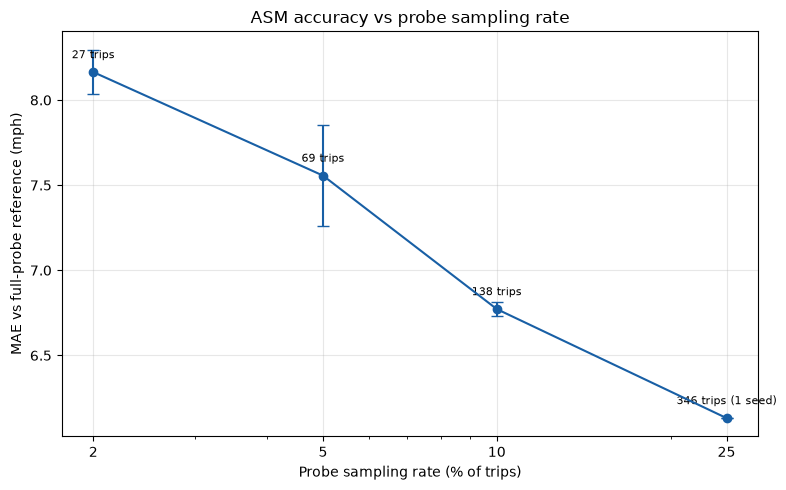

In [46]:
# Purpose: regenerate the sweep figure with readable axis labels and an
# honest note about the single-seed point.
#
# ScalarFormatter overrides matplotlib's default scientific notation on log
# axes. set_xticks with explicit values ensures ticks land on the rates we
# actually ran, not on matplotlib's chosen decades.

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import pandas as pd
from pathlib import Path

sweep = pd.read_csv(Path.cwd() / "data" / "processed" / "asm_sweep.csv")
agg = sweep.groupby("rate").agg(
    mae_mean=("mae", "mean"), mae_std=("mae", "std"),
    n_trips=("n_trips", "first"), n_seeds=("seed", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(agg["rate"] * 100, agg["mae_mean"], yerr=agg["mae_std"].fillna(0),
            marker="o", capsize=4, color="#185FA5", zorder=3)

ax.set_xscale("log")
# Force plain-number ticks at the rates actually tested.
ax.set_xticks([2, 5, 10, 25])
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(plt.NullFormatter())   # suppress 3x10^0 clutter

ax.set_xlabel("Probe sampling rate (% of trips)")
ax.set_ylabel("MAE vs full-probe reference (mph)")
ax.set_title("ASM accuracy vs probe sampling rate")
ax.grid(alpha=0.3, zorder=0)

for _, r in agg.iterrows():
    # Flag the single-seed point so the missing error bar is explained.
    note = f"{int(r.n_trips)} trips" + ("" if r.n_seeds > 1 else " (1 seed)")
    ax.annotate(note, (r["rate"] * 100, r["mae_mean"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8)

plt.tight_layout()
fig.savefig(Path.cwd() / "figures" / "penetration_sweep.png",
            dpi=110, bbox_inches="tight")
plt.show()

In [47]:
# Purpose: assemble loop detector speeds into a lookup we can score against
# repeatedly. Doing this once, outside the sweep loop, avoids recomputing it
# 18 times.
#
# We keep the loop readings as SCATTERED POINTS (time, position, speed)
# rather than gridding them. Gridding would average multiple 30-second
# readings into one cell and lose resolution; sampling the estimate at each
# reading's exact location preserves every measurement.

import numpy as np
from src.evaluation import sample_field_at

# Loop readings already restricted to the study domain, with speeds derived.
gt = loops_study[loops_study["speed_loop"].notna()].copy()

gt_t = gt["hours_elapsed"].values
gt_x = gt["abs_pm"].values
gt_v = gt["speed_loop"].values

print(f"Loop ground-truth points: {len(gt):,}")
print(f"Detectors: {gt['fk_pems_id'].nunique()}")
print(f"Time span: {gt_t.min():.2f} - {gt_t.max():.2f} hours")

# Verify the sampling helper works by scoring the existing ASM field.
# This should roughly reproduce the MAE 8.93 we computed earlier.
check = sample_field_at(asm_full, t_edges, x_edges, gt_t, gt_x)
m = np.isfinite(check)
d = check[m] - gt_v[m]
print(f"\nSanity check -- ASM (full probes) vs loops:")
print(f"  n={m.sum():,}  MAE {np.abs(d).mean():.2f}  bias {d.mean():+.2f}")

Loop ground-truth points: 18,188
Detectors: 19
Time span: 0.44 - 8.44 hours

Sanity check -- ASM (full probes) vs loops:
  n=18,188  MAE 8.96  bias -5.48


In [48]:
# Purpose: rerun the penetration sweep with INDEPENDENT scoring. Identical
# subsampling to before (same seeds, same rates), but error is measured
# against loop detectors rather than the full probe set.
#
# This removes the circularity: the ground truth was recorded by pavement
# sensors that had no connection to the experiment, so the resulting numbers
# measure actual accuracy rather than self-consistency.
#
# Results save after every run so an interrupt loses nothing.

import numpy as np, pandas as pd, time
from pathlib import Path
from src.data import subsample_trips
from src.estimators import asm_estimate as asm_mod
from src.evaluation import sample_field_at

RATES = [0.02, 0.05, 0.10, 0.25]
SEEDS = [0, 1, 2]
OUT = Path.cwd() / "data" / "processed"

results = []
t_start = time.time()

for rate in RATES:
    for seed in SEEDS:
        sub = subsample_trips(nb_study, rate, seed=seed)

        t0 = time.time()
        est = asm_mod(sub["speed"].values, sub["hours_elapsed"].values,
                      sub["postmile_abs"].values, t_centers, x_centers)
        runtime = time.time() - t0

        # Sample the estimate at each loop reading's exact time and place.
        pred = sample_field_at(est, t_edges, x_edges, gt_t, gt_x)
        m = np.isfinite(pred)
        d = pred[m] - gt_v[m]
        truth = gt_v[m]

        row = {
            "rate": rate, "seed": seed,
            "n_trips": sub["trip_id"].nunique(), "n_obs": len(sub),
            "n_scored": int(m.sum()),
            "mae": np.abs(d).mean(),
            "rmse": np.sqrt((d**2).mean()),
            "bias": d.mean(),
            "corr": np.corrcoef(pred[m], truth)[0, 1],
            # Regime split uses LOOP speed to classify, so the binning is
            # independent of the probe data being scored.
            "mae_cong": np.abs(d[truth < 30]).mean(),
            "mae_trans": np.abs(d[(truth >= 30) & (truth < 50)]).mean(),
            "mae_free": np.abs(d[truth >= 50]).mean(),
            "runtime_s": runtime,
        }
        results.append(row)
        pd.DataFrame(results).to_csv(OUT / "asm_sweep_loops.csv", index=False)

        print(f"rate {rate:>5.0%} seed {seed} | {row['n_trips']:>4} trips | "
              f"MAE {row['mae']:5.2f} corr {row['corr']:.3f} "
              f"bias {row['bias']:+5.2f} | {runtime:5.1f}s "
              f"| total {(time.time()-t_start)/60:.1f} min")

print("\nSaved to", OUT / "asm_sweep_loops.csv")

rate    2% seed 0 |   27 trips | MAE 10.73 corr 0.773 bias -4.33 |  25.6s | total 0.4 min
rate    2% seed 1 |   27 trips | MAE 11.29 corr 0.760 bias -5.00 |  17.2s | total 0.7 min
rate    2% seed 2 |   27 trips | MAE 10.63 corr 0.745 bias -4.65 |  19.4s | total 1.0 min
rate    5% seed 0 |   69 trips | MAE 10.81 corr 0.762 bias -4.71 |  44.4s | total 1.8 min
rate    5% seed 1 |   69 trips | MAE 10.21 corr 0.802 bias -5.39 |  45.2s | total 2.5 min
rate    5% seed 2 |   69 trips | MAE 10.12 corr 0.788 bias -4.30 |  47.9s | total 3.3 min
rate   10% seed 0 |  138 trips | MAE  9.81 corr 0.816 bias -5.68 | 155.2s | total 5.9 min
rate   10% seed 1 |  138 trips | MAE  9.65 corr 0.806 bias -4.59 | 107.0s | total 7.7 min
rate   10% seed 2 |  138 trips | MAE  9.81 corr 0.815 bias -5.63 |  82.6s | total 9.1 min
rate   25% seed 0 |  346 trips | MAE  9.33 corr 0.842 bias -5.85 | 218.2s | total 12.7 min
rate   25% seed 1 |  346 trips | MAE  9.27 corr 0.834 bias -5.30 | 205.1s | total 16.2 min
rate   2

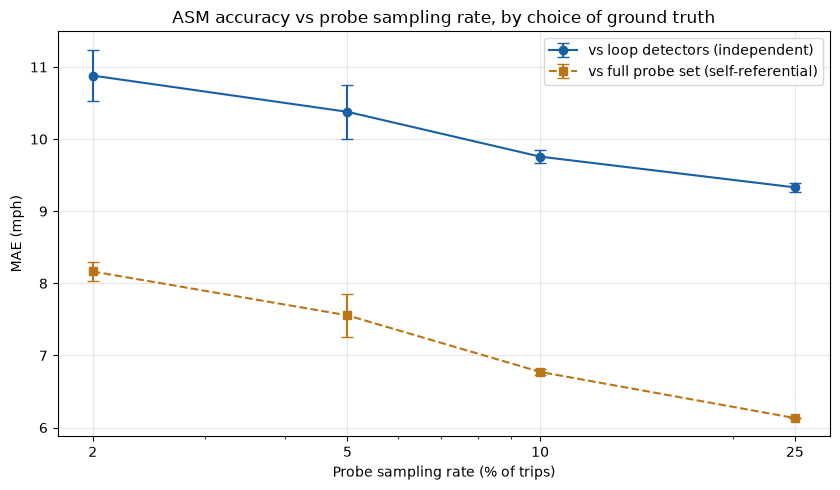

      trips    mae  mae_sd  corr  bias  mae_cong  mae_free
rate                                                      
0.02     27  10.88    0.36  0.76 -4.66      8.01     12.89
0.05     69  10.38    0.38  0.78 -4.80      7.24     12.39
0.10    138   9.76    0.09  0.81 -5.30      5.82     11.92
0.25    346   9.33    0.07  0.83 -5.54      4.87     11.34


In [49]:
# Purpose: plot both sweeps together -- the circular self-comparison and the
# independent loop-based scoring. Showing them side by side IS the point:
# it demonstrates that the choice of ground truth materially changes the
# conclusion, which is a methodological finding in itself.

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import pandas as pd
from pathlib import Path

OUT = Path.cwd() / "data" / "processed"
circ = pd.read_csv(OUT / "asm_sweep.csv").groupby("rate")["mae"].agg(["mean", "std"])
loop = pd.read_csv(OUT / "asm_sweep_loops.csv").groupby("rate")["mae"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.errorbar(loop.index * 100, loop["mean"], yerr=loop["std"].fillna(0),
            marker="o", capsize=4, color="#185FA5", zorder=3,
            label="vs loop detectors (independent)")
ax.errorbar(circ.index * 100, circ["mean"], yerr=circ["std"].fillna(0),
            marker="s", capsize=4, color="#BA7517", zorder=3, linestyle="--",
            label="vs full probe set (self-referential)")

ax.set_xscale("log")
ax.set_xticks([2, 5, 10, 25])
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("Probe sampling rate (% of trips)")
ax.set_ylabel("MAE (mph)")
ax.set_title("ASM accuracy vs probe sampling rate, by choice of ground truth")
ax.grid(alpha=0.3, zorder=0)
ax.legend()

plt.tight_layout()
fig.savefig(Path.cwd() / "figures" / "penetration_sweep.png",
            dpi=110, bbox_inches="tight")
plt.show()

# Table values for the README.
tbl = pd.read_csv(OUT / "asm_sweep_loops.csv").groupby("rate").agg(
    trips=("n_trips", "first"), mae=("mae", "mean"), mae_sd=("mae", "std"),
    corr=("corr", "mean"), bias=("bias", "mean"),
    mae_cong=("mae_cong", "mean"), mae_free=("mae_free", "mean"))
print(tbl.round(2).to_string())